# Laboratorio 05 — Análisis de pacientes con `clinlab`
Alejandro García Colorado · A partir del notebook del laboratorio 2.

El paquete contiene transformaciones puras; este notebook conserva la lectura,
la coordinación de bloques y la presentación de resultados. Se usan los CSV locales
originales, sin copiarlos al repositorio. Las comparaciones de motores, intentos de
optimización y scripts experimentales permanecen en el notebook original del lab 2
(y en el historial Git), no se ejecutan aquí.

**Primera ejecución:** procesa los primeros dos bloques de encuentros y observaciones.
Este subconjunto es una prueba de integración, no una muestra representativa.
Para analizar todo el dataset, cambia `MAX_CHUNKS = None` y reinicia el kernel.
Se conserva en memoria una tabla mínima de encuentros para validar las uniones,
además de pacientes y las mediciones seleccionadas de HbA1c. No se materializan
las 17 millones de observaciones ni su unión completa; no se garantiza un límite
estricto de 200 MiB de memoria del proceso.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from clinlab import (
    classify_age_group,
    convert_numeric_observations,
    egfr_ckd_epi_2021,
    find_duplicate_patient_ids,
    flag_impossible_encounters,
    flag_patient_sentinels,
    merge_with_patient_data,
)

DATA_DIR = Path(
    os.environ.get(
        "CLINLAB_DATA_DIR",
        str(Path.home() / "EE_CDB/lab02/data/synthea_20000/csv"),
    )
).expanduser()
CHUNKSIZE = 50_000
MAX_CHUNKS = None  # None: cohorte completa; 2: comprobación inicial por prefijo.
REFERENCE_DATE = pd.Timestamp("2026-08-22", tz="UTC")

paths = {
    name: DATA_DIR / f"{name}.csv"
    for name in ("patients", "encounters", "observations")
}
for path in paths.values():
    if not path.is_file():
        raise FileNotFoundError(f"Falta el CSV local: {path}")

print("Datos:", DATA_DIR)
print("Modo:", "COMPLETO" if MAX_CHUNKS is None else "PARCIAL: primeros bloques")
display(
    pd.DataFrame(
        {
            "archivo": paths.keys(),
            "MiB_en_disco": [p.stat().st_size / 1024**2 for p in paths.values()],
        }
    )
)

Datos: /Users/alejandrogarciacolorado/EE_CDB/lab02/data/synthea_20000/csv
Modo: COMPLETO


,archivo,MiB_en_disco
0,patients,6.570528
1,encounters,443.404392
2,observations,2973.109505


## 1. Pacientes y auditoría de identificadores
Se cargan únicamente las columnas necesarias como texto. Los identificadores no
se convierten a números. Las fechas originales se conservan para distinguir una
fecha imposible de una fecha ausente. Los duplicados se muestran antes de detener
una unión que podría multiplicar filas.

In [2]:
patients = pd.read_csv(
    paths["patients"],
    usecols=["Id", "BIRTHDATE", "DEATHDATE", "GENDER", "RACE", "ETHNICITY"],
    dtype="string",
)
duplicates = find_duplicate_patient_ids(patients)
display(duplicates.head(10))
if patients["Id"].isna().any() or not duplicates.empty:
    raise ValueError("La tabla de pacientes debe tener Id presentes y únicos")
display(patients.isna().sum().rename("faltantes").to_frame())
print("Pacientes:", len(patients))

,Id,BIRTHDATE,DEATHDATE,RACE,ETHNICITY,GENDER


,faltantes
Id,0
BIRTHDATE,0
DEATHDATE,20000
RACE,0
ETHNICITY,0
GENDER,0


Pacientes: 23006


## 2. Edad en años cumplidos y grupos etarios
La fecha de referencia es explícita para que la ejecución sea reproducible.
Para personas fallecidas antes de ella se usa la fecha de defunción. Las fechas
inválidas, futuras o cronologías negativas producen una edad ausente y se cuentan;
no se inventan edades ni se elimina al paciente.

In [3]:
birth = pd.to_datetime(
    patients["BIRTHDATE"], errors="coerce", format="ISO8601", utc=True
).dt.normalize()
death = pd.to_datetime(
    patients["DEATHDATE"], errors="coerce", format="ISO8601", utc=True
).dt.normalize()
reference = pd.Series(REFERENCE_DATE, index=patients.index)
reference = reference.where(death.isna() | death.gt(REFERENCE_DATE), death)
invalid_death = patients["DEATHDATE"].notna() & death.isna()
before_birthday = (reference.dt.month < birth.dt.month) | (
    (reference.dt.month == birth.dt.month) & (reference.dt.day < birth.dt.day)
)
age = (reference.dt.year - birth.dt.year - before_birthday.astype(int)).astype("Int64")
patients["age"] = age.mask(birth.isna() | invalid_death | birth.gt(reference))
patients["age_group"] = classify_age_group(patients["age"])
print("Edades sin calcular:", int(patients["age"].isna().sum()))
display(patients["age_group"].value_counts(dropna=False).rename("pacientes"))
display(pd.crosstab(patients["RACE"], patients["ETHNICITY"]))

Edades sin calcular: 0


age_group
middle_aged_adult    8050
young_adult          6275
minor                4468
older_adult          4213
Name: pacientes, dtype: Int64

ETHNICITY,hispanic,nonhispanic
RACE,,
asian,158,1236
black,266,1585
hawaiian,33,232
native,12,70
other,33,232
white,1959,17190


## 3. Cronología de encuentros por bloques
`flag_impossible_encounters` compara días de calendario en UTC. No considera
posterior a la defunción un encuentro en ese mismo día. Una marca post mortem
es un aviso para revisión: en el lab 2 muchos registros fueron administrativos
(`Death Certification`). No se eliminan automáticamente.

La tabla mínima de llaves se lee completa incluso en modo parcial: así, una
observación no se marca como huérfana por haber omitido su encuentro del prefijo.
La auditoría temporal sí respeta `MAX_CHUNKS`.

In [4]:
flag_names = [
    "visit_before_birth",
    "start_after_death",
    "stop_after_death",
    "invalid_start_date",
    "invalid_stop_date",
    "invalid_birth_date",
    "invalid_death_date",
]
encounter_flags = pd.Series(0, index=flag_names, dtype="int64")
lookup_parts = []
examples = []
encounters_audited = 0
orphan_encounters = 0
with pd.read_csv(
    paths["encounters"],
    usecols=["Id", "PATIENT", "START", "STOP", "DESCRIPTION"],
    dtype="string",
    chunksize=CHUNKSIZE,
) as reader:
    for number, chunk in enumerate(reader):
        lookup_parts.append(
            chunk[["Id", "PATIENT"]].rename(
                columns={
                    "Id": "ENCOUNTER_KEY",
                    "PATIENT": "PATIENT_ENCOUNTER",
                }
            )
        )
        if MAX_CHUNKS is None or number < MAX_CHUNKS:
            checked = flag_impossible_encounters(
                chunk.drop(columns="Id"),
                patients,
            )
            encounters_audited += len(chunk)
            orphan_encounters += int((~chunk["PATIENT"].isin(patients["Id"])).sum())
            encounter_flags += checked[flag_names].sum().astype("int64")
            if sum(len(x) for x in examples) < 20:
                examples.append(checked.loc[checked[flag_names].any(axis=1)].head(5))
            del checked
encounter_lookup = pd.concat(lookup_parts, ignore_index=True)
del lookup_parts
if (
    encounter_lookup["ENCOUNTER_KEY"].isna().any()
    or not find_duplicate_patient_ids(encounter_lookup, id_column="ENCOUNTER_KEY").empty
):
    raise ValueError("Los identificadores de encuentro deben ser únicos y presentes")
print("Encuentros auditados:", encounters_audited)
print("Encuentros sin paciente conocido:", orphan_encounters)
display(encounter_flags.rename("encuentros_marcados").to_frame())
if examples:
    display(pd.concat(examples, ignore_index=True).head(20))

Encuentros auditados: 1399646
Encuentros sin paciente conocido: 0


,encuentros_marcados
visit_before_birth,0
start_after_death,2849
stop_after_death,3340
invalid_start_date,0
invalid_stop_date,0
invalid_birth_date,0
invalid_death_date,0


,START,STOP,PATIENT,DESCRIPTION,Id,BIRTHDATE,DEATHDATE,invalid_start_date,invalid_stop_date,invalid_birth_date,invalid_death_date,visit_before_birth,start_after_death,stop_after_death
0,2021-09-20T16:50:01Z,2021-09-20T17:05:01Z,2b07a4bc-cfe9-d92c-8ee3-68547da81d80,Death Certification,2b07a4bc-cfe9-d92c-8ee3-68547da81d80,1947-04-28,2021-09-17,False,False,False,False,False,True,True
1,1993-12-24T12:27:16Z,1993-12-24T12:42:16Z,c8984cad-9087-713d-5dd8-c732f62090eb,Death Certification,c8984cad-9087-713d-5dd8-c732f62090eb,1989-04-14,1993-12-19,False,False,False,False,False,True,True
2,2020-06-30T18:17:04Z,2020-06-30T18:32:04Z,0c43a2c9-7466-aabc-20c0-f97f0ff7127d,Death Certification,0c43a2c9-7466-aabc-20c0-f97f0ff7127d,1976-09-07,2020-06-23,False,False,False,False,False,True,True
3,2021-06-26T13:17:34Z,2021-06-26T13:32:34Z,4c47026f-465e-137b-d51f-b3bbf3729815,Death Certification,4c47026f-465e-137b-d51f-b3bbf3729815,1988-03-05,2021-06-24,False,False,False,False,False,True,True
4,2018-08-11T09:22:49Z,2018-08-11T09:37:49Z,cf77d184-48aa-35e5-619b-03d0c55adf0f,Death Certification,cf77d184-48aa-35e5-619b-03d0c55adf0f,1944-06-24,2018-08-10,False,False,False,False,False,True,True
5,2018-09-14T23:41:56Z,2018-09-14T23:56:56Z,753e7ce6-008d-25e6-aa25-018ca4f9b7e2,Death Certification,753e7ce6-008d-25e6-aa25-018ca4f9b7e2,1938-11-04,2018-09-06,False,False,False,False,False,True,True
6,2011-08-08T01:35:48Z,2011-09-01T01:35:48Z,e2986d41-1e2f-566c-64d0-57c3ee822690,Admission to hospice (procedure),e2986d41-1e2f-566c-64d0-57c3ee822690,1944-06-04,2011-08-31,False,False,False,False,False,False,True
7,2011-09-05T01:35:48Z,2011-09-05T01:50:48Z,e2986d41-1e2f-566c-64d0-57c3ee822690,Death Certification,e2986d41-1e2f-566c-64d0-57c3ee822690,1944-06-04,2011-08-31,False,False,False,False,False,True,True
8,1993-09-04T12:27:59Z,1993-09-04T12:42:59Z,d00a847f-da2d-fc30-c4c3-614ac1b5749c,Death Certification,d00a847f-da2d-fc30-c4c3-614ac1b5749c,1972-02-26,1993-08-29,False,False,False,False,False,True,True
9,1986-02-08T12:27:59Z,1986-02-08T12:42:59Z,08ef0133-37ae-cbc0-1c2a-2696e8bbca82,Death Certification,08ef0133-37ae-cbc0-1c2a-2696e8bbca82,1972-02-26,1986-02-04,False,False,False,False,False,True,True


## 4. Observaciones, conversión numérica y unión de las tres tablas
Las observaciones cualitativas conservan `VALUE`; solo `TYPE = numeric` produce
`VALUE_NUMERIC`. La primera unión es observación–encuentro, y la segunda sigue el
paciente del encuentro. Ambas usan la función del paquete con `many_to_one`.
Se cuenta por separado si el paciente de la observación difiere del encuentro.
Las observaciones sin encuentro se conservan; su paciente directo se puede usar
para HbA1c, sin presentarlo como una coincidencia de la ruta estricta.

Se selecciona LOINC `4548-4` y se comprueba que la unidad sea `%` antes de analizar
HbA1c. Valores en otra unidad se cuentan y no se mezclan con porcentajes.

In [5]:
counts = {
    "observaciones": 0,
    "sin_encuentro": 0,
    "sin_paciente_via_encuentro": 0,
    "sin_paciente_directo": 0,
    "pacientes_discordantes": 0,
    "numeric_no_convertible": 0,
    "cualitativas": 0,
    "hba1c_unidad_no_porcentaje": 0,
}
code_counts = pd.Series(dtype="int64")
hba_parts = []
max_join_mib = 0.0
patient_lookup = patients[["Id"]].rename(columns={"Id": "PATIENT_KEY"})
columns = ["DATE", "PATIENT", "ENCOUNTER", "CODE", "VALUE", "UNITS", "TYPE"]
with pd.read_csv(
    paths["observations"], usecols=columns, dtype="string", chunksize=CHUNKSIZE
) as reader:
    for number, chunk in enumerate(reader):
        if MAX_CHUNKS is not None and number >= MAX_CHUNKS:
            break
        numeric = convert_numeric_observations(chunk)
        joined = merge_with_patient_data(
            numeric,
            encounter_lookup,
            record_patient_id="ENCOUNTER",
            patient_id="ENCOUNTER_KEY",
            patient_columns=["PATIENT_ENCOUNTER"],
        )
        joined = merge_with_patient_data(
            joined,
            patient_lookup,
            record_patient_id="PATIENT_ENCOUNTER",
            patient_id="PATIENT_KEY",
            patient_columns=[],
        )
        assert len(joined) == len(chunk)
        counts["observaciones"] += len(chunk)
        counts["sin_encuentro"] += int(joined["ENCOUNTER_KEY"].isna().sum())
        counts["sin_paciente_via_encuentro"] += int(joined["PATIENT_KEY"].isna().sum())
        counts["sin_paciente_directo"] += int(
            (~chunk["PATIENT"].isin(patients["Id"])).sum()
        )
        comparable = joined["PATIENT"].notna() & joined["PATIENT_ENCOUNTER"].notna()
        counts["pacientes_discordantes"] += int(
            (comparable & joined["PATIENT"].ne(joined["PATIENT_ENCOUNTER"])).sum()
        )
        is_numeric = numeric["TYPE"].str.strip().str.lower().eq("numeric").fillna(False)
        counts["numeric_no_convertible"] += int(
            (
                is_numeric & numeric["VALUE"].notna() & numeric["VALUE_NUMERIC"].isna()
            ).sum()
        )
        counts["cualitativas"] += int(numeric["TYPE"].str.lower().eq("text").sum())
        code_counts = code_counts.add(chunk["CODE"].value_counts(), fill_value=0)
        is_hba = numeric["CODE"].eq("4548-4").fillna(False)
        percent = numeric["UNITS"].str.strip().eq("%").fillna(False)
        counts["hba1c_unidad_no_porcentaje"] += int((is_hba & ~percent).sum())
        selected = numeric.loc[is_hba & percent, ["DATE", "PATIENT", "VALUE_NUMERIC"]]
        if not selected.empty:
            hba_parts.append(selected.copy())
        max_join_mib = max(max_join_mib, joined.memory_usage(deep=True).sum() / 1024**2)
        del numeric, joined

display(pd.Series(counts).rename("filas").to_frame())
display(code_counts.sort_values(ascending=False).head(10).astype("int64"))
print("Mayor tabla unida por bloque, MiB (no es el pico del proceso):", max_join_mib)

,filas
observaciones,17677231
sin_encuentro,625476
sin_paciente_via_encuentro,625476
sin_paciente_directo,0
pacientes_discordantes,0
numeric_no_convertible,0
cualitativas,6749484
hba1c_unidad_no_porcentaje,0


CODE
72514-3    584224
8480-6     332352
8462-4     332352
29463-7    315939
9279-1     308985
8867-4     308985
8302-2     302565
72166-2    301694
39156-5    280744
74006-8    245248
dtype: int64

Mayor tabla unida por bloque, MiB (no es el pico del proceso): 34.695908546447754


## 5. HbA1c: centinelas, distribución y resumen por paciente
Se marca HbA1c de 0% y edad de 180 años sin modificar los valores originales.
El promedio analítico excluye esos centinelas, valores no numéricos y pacientes
sin coincidencia. Esto no es un filtro completo de rangos clínicos. Un valor de
HbA1c bajo no se descarta por el umbral analítico de otro ensayo.

El número de mediciones válidas por paciente se distingue del número de registros.
La media de todas las mediciones y la media de las medias individuales responden
preguntas diferentes. Si en modo parcial no hay HbA1c, se informa sin fallar.

Registros HbA1c en %: 181975


age_sentinel      0
hba1c_sentinel    0
Name: centinelas, dtype: int64

count    181975.0
mean     4.630303
std      1.433644
min           2.3
25%           3.2
50%           4.4
75%           6.0
max          10.9
Name: hba1c, dtype: Float64

pacientes_con_hba1c                   9827.000000
pacientes_con_3_mediciones_validas    8836.000000
media_de_mediciones_porcentaje           4.630303
media_de_medias_porcentaje               5.701747
dtype: float64

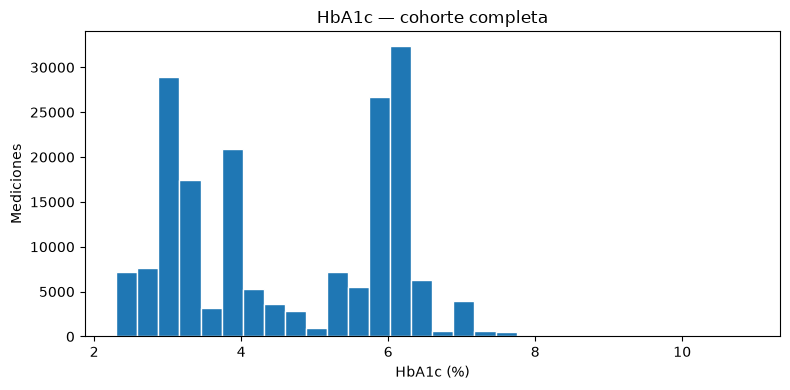

In [6]:
if hba_parts:
    hba = pd.concat(hba_parts, ignore_index=True).rename(
        columns={"VALUE_NUMERIC": "hba1c"}
    )
else:
    hba = pd.DataFrame(
        {
            "DATE": pd.Series(dtype="string"),
            "PATIENT": pd.Series(dtype="string"),
            "hba1c": pd.Series(dtype="Float64"),
        }
    )
del hba_parts
hba = merge_with_patient_data(hba, patients, patient_columns=["age", "age_group"])
hba = flag_patient_sentinels(hba)
print("Registros HbA1c en %:", len(hba))
display(hba[["age_sentinel", "hba1c_sentinel"]].sum().rename("centinelas"))
valid_hba = hba.loc[
    hba["hba1c"].notna()
    & hba["Id"].notna()
    & ~hba["hba1c_sentinel"]
    & ~hba["age_sentinel"]
].copy()
if valid_hba.empty:
    print("No hay HbA1c analizable en los bloques procesados.")
else:
    summary = valid_hba.groupby("PATIENT")["hba1c"].agg(["count", "mean"])
    display(valid_hba["hba1c"].describe())
    display(
        pd.Series(
            {
                "pacientes_con_hba1c": len(summary),
                "pacientes_con_3_mediciones_validas": int(summary["count"].ge(3).sum()),
                "media_de_mediciones_porcentaje": valid_hba["hba1c"].mean(),
                "media_de_medias_porcentaje": summary["mean"].mean(),
            }
        )
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(valid_hba["hba1c"].astype(float), bins=30, edgecolor="white")
    ax.set(
        xlabel="HbA1c (%)",
        ylabel="Mediciones",
        title="HbA1c — "
        + ("cohorte completa" if MAX_CHUNKS is None else "prefijo parcial"),
    )
    fig.tight_layout()
    plt.show()

## 6. Cálculo clínico independiente: CKD-EPI 2021
La función añadida en el lab 5 se valida contra ocho casos externos en
`tests/test_clinical.py` (NKF, consulta 2026-09-10). Este ejemplo es sintético:
no interpreta HbA1c como creatinina ni calcula eGFR de pacientes sin esos datos.
Las unidades de salida son mL/min/1.73 m².

In [7]:
display(
    pd.DataFrame(
        [
            {
                "creatinina_mg_dl": 0.9,
                "edad_anios": 40,
                "sexo_ecuacion": "male",
                "egfr_ml_min_1_73m2": egfr_ckd_epi_2021(0.9, 40, "male"),
            }
        ]
    )
)

,creatinina_mg_dl,edad_anios,sexo_ecuacion,egfr_ml_min_1_73m2
0,0.9,40,male,110.7256


## 7. Interpretación y trazabilidad
Las salidas de arriba pertenecen a esta ejecución. No se fijan conteos de filas
como asserts porque pueden cambiar entre piloto, prefijo y cohorte completa.
Las banderas señalan revisión, no diagnósticos. Faltantes, fechas inválidas y
ausencia de llaves deben interpretarse por separado.

**Antecedentes, no resultados recalculados:** en el lab 2 se documentaron
2,849 encuentros iniciados después de la defunción, de los cuales 2,780 fueron
`Death Certification`; no se detectaron encuentros previos al nacimiento.
Los valores de texto de observaciones fueron cualitativos válidos.
La unión estricta dejaba sin encuentro 625,476 observaciones que podían enlazarse
directamente con pacientes. El notebook original conserva tablas, benchmarks,
formato ancho y criterios de rangos operativos de aquel laboratorio.

Este notebook del lab 5 reproduce el núcleo de auditoría, uniones y HbA1c mediante
el paquete. No vuelve a ejecutar el benchmark de motores ni el pipeline de formato
ancho. Para entregar, ejecutar desde kernel limpio, conservar los resultados
actuales y registrar si `MAX_CHUNKS` fue 2 o None.